# Customer Churn Prediction — dunnhumby "Complete Journey"

This notebook builds a churn model for a grocery retailer, using the
dunnhumby "Complete Journey" dataset: ~2,500 households, 711 days of
transactions, plus product, demographic, coupon and campaign tables.

**Objective:** predict which households are at risk of churning — defined
as making no purchase in the 28 days following a cutoff point — from their
prior shopping behaviour.

**Roadmap:**

1. **Defining Churn** — the label definition, and the data-leakage trap it has to avoid.
2. **Data prep** — load and clean the eight raw tables.
3. **Data Exploration** — check the transaction panel for timing artefacts.
4. **Building the label** — turn the definition into an actual `churn` column.
5. **Test and Training Split** — hold out households for final evaluation.
6. **Building Features** — turn transactions into a household-level feature matrix.
7. **EDA** — see how each feature relates to churn.
8. **Baseline** — a one-column rule every model has to beat.
9. **First Cross Validation** — compare models against the baseline.
10. **Tuning Hyperparameters** — search around the best-performing model.
11. **Re-engineering features** — test additional candidate signals (coupons, campaigns, store concentration).

# Defining Churn

The dataset has no churn column, so we build one:

- A household has churned if it made **no purchase in the 28 days following a cutoff point T**.

### The trap

The approach of having label churn over the last 28 days (684-711) and
build features from the full history (1-711) silently breaks.
Recency measured at day 711 gives `recency > 28 -> churn = 1` with no exceptions.
The feature *is* the label. The model scores near-perfect AUC and has
learned nothing. This is **data leakage**. Spend and purchase counts are
contaminated the same way, more subtly.

### The fix: two non-overlapping windows

    days 1 ................ 683 | 684 ......... 711
    +-- observation window -----+ +-- outcome window --+
            FEATURES only              LABEL only
                              T = 683

Recency is now measured at T, and the identity breaks:

| household | last purchase <= 683 | recency_at_T | bought in 684-711? | churn |
|-----------|----------------------|--------------|--------------------|-------|
| 1042      | day 660              | 23           | no                 | 1     |
| 2088      | day 660              | 23           | yes (day 690)      | 0     |

Same feature, different labels. Recency stays a strong signal, but it is
now a clue rather than the answer.

**Working rule:** every feature aggregation carries `DAY <= 683`. Any
aggregation without it is assumed to leak until proven otherwise.

**Eligible population:** only households with at least one purchase in
the 90 days before T (594-683). Anyone quieter than that left long ago
and isn't churning now.

**Note:** T splits *time* to build a clean label. The train/test split
comes later and splits *households*. Different cuts, different purposes.

# Data prep

Initial exploration of the **8 raw datasets available to this project**.
The goal here is to load each table, inspect its structure (shape, keys, nulls,
data types), apply light cleaning, and get it ready for feature building.

In [1]:
# Confirm the dataset path resolves and list the available CSVs
import glob
hits = glob.glob("/kaggle/input/**/*.csv", recursive=True)
print(f"{len(hits)} CSV files found:")
for h in hits:
    print(" ", h)

8 CSV files found:
  /kaggle/input/datasets/frtgnn/dunnhumby-the-complete-journey/campaign_table.csv
  /kaggle/input/datasets/frtgnn/dunnhumby-the-complete-journey/causal_data.csv
  /kaggle/input/datasets/frtgnn/dunnhumby-the-complete-journey/coupon.csv
  /kaggle/input/datasets/frtgnn/dunnhumby-the-complete-journey/campaign_desc.csv
  /kaggle/input/datasets/frtgnn/dunnhumby-the-complete-journey/product.csv
  /kaggle/input/datasets/frtgnn/dunnhumby-the-complete-journey/transaction_data.csv
  /kaggle/input/datasets/frtgnn/dunnhumby-the-complete-journey/hh_demographic.csv
  /kaggle/input/datasets/frtgnn/dunnhumby-the-complete-journey/coupon_redempt.csv


In [2]:
# Define the path to access the databases
from pathlib import Path
RAW_PATH = Path("/kaggle/input/datasets/frtgnn/dunnhumby-the-complete-journey")

## Transactions data

**Data quality checks**

Before transforming the table, confirm that the assumed composite key (`household_key`, `BASKET_ID`, `PRODUCT_ID`) is actually unique, and check for missing values that would need to be handled.

In [3]:
# Load the transactions table and check its shape and first rows
import pandas as pd
import matplotlib.pyplot as plt

transactions = pd.read_csv(RAW_PATH / "transaction_data.csv")
print(transactions.shape)
transactions.head()

(2595732, 12)


,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,RETAIL_DISC,TRANS_TIME,WEEK_NO,COUPON_DISC,COUPON_MATCH_DISC
0,2375,26984851472,1,1004906,1,1.39,364,-0.60,1631,1,0.0,0.0
1,2375,26984851472,1,1033142,1,0.82,364,0.00,1631,1,0.0,0.0
2,2375,26984851472,1,1036325,1,0.99,364,-0.30,1631,1,0.0,0.0
3,2375,26984851472,1,1082185,1,1.21,364,0.00,1631,1,0.0,0.0
4,2375,26984851472,1,8160430,1,1.50,364,-0.39,1631,1,0.0,0.0


In [4]:
# Range of days covered by the transactions table
print(transactions["DAY"].min(), transactions["DAY"].max())

# Count of distinct households present in transactions
print(transactions["household_key"].nunique())

1 711
2500


In [5]:
# Verify that household_key + BASKET_ID + PRODUCT_ID together form a unique key (no duplicate rows for the same product in the same basket)
key_cols = ["household_key", "BASKET_ID", "PRODUCT_ID"]
print(transactions.shape[0])
print(transactions.duplicated(subset=key_cols).sum())

2595732
0


In [6]:
# Check for missing values in every column
transactions.isnull().sum()

household_key        0
BASKET_ID            0
DAY                  0
PRODUCT_ID           0
QUANTITY             0
SALES_VALUE          0
STORE_ID             0
RETAIL_DISC          0
TRANS_TIME           0
WEEK_NO              0
COUPON_DISC          0
COUPON_MATCH_DISC    0
dtype: int64

**Transactions: clean.** The composite key (`household_key`, `BASKET_ID`,
`PRODUCT_ID`) is unique and there are no missing values in any column. No
cleaning is needed before this table is used for feature aggregation.

## Product Table
Product catalog with department, brand and commodity/sub-commodity descriptions, keyed by PRODUCT_ID.

In [7]:
# Load the product table and confirm PRODUCT_ID is a unique key
product = pd.read_csv(RAW_PATH / "product.csv")
print(product.shape)
# Confirming Key
print(product["PRODUCT_ID"].duplicated().sum())
product.head()

(92353, 7)
0


,PRODUCT_ID,MANUFACTURER,DEPARTMENT,BRAND,COMMODITY_DESC,SUB_COMMODITY_DESC,CURR_SIZE_OF_PRODUCT
0,25671,2,GROCERY,National,FRZN ICE,ICE - CRUSHED/CUBED,22 LB
1,26081,2,MISC. TRANS.,National,NO COMMODITY DESCRIPTION,NO SUBCOMMODITY DESCRIPTION,
2,26093,69,PASTRY,Private,BREAD,BREAD:ITALIAN/FRENCH,
3,26190,69,GROCERY,Private,FRUIT - SHELF STABLE,APPLE SAUCE,50 OZ
4,26355,69,GROCERY,Private,COOKIES/CONES,SPECIALTY COOKIES,14 OZ


`PRODUCT_ID` is a clean, unique key, so joining transactions to this table
for department/brand/commodity lookups is safe with no duplication risk.

## Household demographics
Household-level demographic attributes (age, income, marital status, household composition, etc.), keyed by household_key.

In [8]:
# Load the household demographic table and confirm household_key is a unique key
hh_demographic = pd.read_csv(RAW_PATH / "hh_demographic.csv")
print(hh_demographic.shape)
print(hh_demographic["household_key"].duplicated().sum())
hh_demographic.head()

(801, 8)
0


,AGE_DESC,MARITAL_STATUS_CODE,INCOME_DESC,HOMEOWNER_DESC,HH_COMP_DESC,HOUSEHOLD_SIZE_DESC,KID_CATEGORY_DESC,household_key
0,65+,A,35-49K,Homeowner,2 Adults No Kids,2,None/Unknown,1
1,45-54,A,50-74K,Homeowner,2 Adults No Kids,2,None/Unknown,7
2,25-34,U,25-34K,Unknown,2 Adults Kids,3,1,8
3,25-34,U,75-99K,Homeowner,2 Adults Kids,4,2,13
4,45-54,B,50-74K,Homeowner,Single Female,1,None/Unknown,16


In [9]:
# Check for missing values in every column
hh_demographic.isnull().sum()

AGE_DESC               0
MARITAL_STATUS_CODE    0
INCOME_DESC            0
HOMEOWNER_DESC         0
HH_COMP_DESC           0
HOUSEHOLD_SIZE_DESC    0
KID_CATEGORY_DESC      0
household_key          0
dtype: int64

In [10]:
# Category distribution of every demographic column, before any cleaning
for c in hh_demographic.select_dtypes("object"):
    print(c, hh_demographic[c].value_counts().to_dict())

AGE_DESC {'45-54': 288, '35-44': 194, '25-34': 142, '65+': 72, '55-64': 59, '19-24': 46}
MARITAL_STATUS_CODE {'U': 344, 'A': 340, 'B': 117}
INCOME_DESC {'50-74K': 192, '35-49K': 172, '75-99K': 96, '25-34K': 77, '15-24K': 74, 'Under 15K': 61, '125-149K': 38, '100-124K': 34, '150-174K': 30, '250K+': 11, '175-199K': 11, '200-249K': 5}
HOMEOWNER_DESC {'Homeowner': 504, 'Unknown': 233, 'Renter': 42, 'Probable Renter': 11, 'Probable Owner': 11}
HH_COMP_DESC {'2 Adults No Kids': 255, '2 Adults Kids': 187, 'Single Female': 144, 'Single Male': 95, 'Unknown': 73, '1 Adult Kids': 47}
HOUSEHOLD_SIZE_DESC {'2': 318, '1': 255, '3': 109, '5+': 66, '4': 53}
KID_CATEGORY_DESC {'None/Unknown': 558, '1': 114, '3+': 69, '2': 60}


**Inferring missing kid category**

`KID_CATEGORY_DESC` is `'None/Unknown'` for a large share of households, which conflates two very different cases: households that genuinely have no kids, and households where the number of kids simply wasn't captured. Household composition (`HH_COMP_DESC`) lets us recover some of that signal — categories like `'2 Adults No Kids'`, `'Single Female'` and `'Single Male'` imply no kids even when `KID_CATEGORY_DESC` doesn't say so explicitly. Use this to build a cleaner `KID_CATEGORY_INFERRED` column.

In [11]:
# Cross-check household composition against the stated kid category to spot the inferable cases
pd.crosstab(hh_demographic["HH_COMP_DESC"], hh_demographic["KID_CATEGORY_DESC"])

KID_CATEGORY_DESC,1,2,3+,None/Unknown
HH_COMP_DESC,,,,
1 Adult Kids,20,14,13,0
2 Adults Kids,88,46,53,0
2 Adults No Kids,0,0,0,255
Single Female,0,0,0,144
Single Male,0,0,0,95
Unknown,6,0,3,64


In [12]:
# KID_CATEGORY_DESC is 'None/Unknown' for many households where we can still infer there are no kids
# from HH_COMP_DESC (e.g. '2 Adults No Kids', 'Single Female', 'Single Male').
# Build a cleaner KID_CATEGORY_INFERRED column: keep the original value when it is known,
# set it to 'None' when the household composition implies no kids, otherwise leave it as 'Unknown'.
import numpy as np

no_kids_categories = ["2 Adults No Kids", "Single Female", "Single Male"]

hh_demographic["KID_CATEGORY_INFERRED"] = np.select(
    [
        hh_demographic["KID_CATEGORY_DESC"] != "None/Unknown",
        hh_demographic["HH_COMP_DESC"].isin(no_kids_categories),
    ],
    [
        hh_demographic["KID_CATEGORY_DESC"],
        "None",
    ],
    default="Unknown",
)

In [13]:
pd.crosstab(hh_demographic["HH_COMP_DESC"], hh_demographic["KID_CATEGORY_INFERRED"])

KID_CATEGORY_INFERRED,1,2,3+,None,Unknown
HH_COMP_DESC,,,,,
1 Adult Kids,20,14,13,0,0
2 Adults Kids,88,46,53,0,0
2 Adults No Kids,0,0,0,255,0
Single Female,0,0,0,144,0
Single Male,0,0,0,95,0
Unknown,6,0,3,0,64


In [14]:
# Check the resulting distribution of the inferred kid category
hh_demographic["KID_CATEGORY_INFERRED"].value_counts()

KID_CATEGORY_INFERRED
None       494
1          114
3+          69
Unknown     64
2           60
Name: count, dtype: int64

**Kid category: partly recovered, not fully.** Household composition lets us
resolve most of the `'None/Unknown'` bucket into a genuine `None`, but the
households whose `HH_COMP_DESC` is itself `'Unknown'` stay `Unknown` here too.
`KID_CATEGORY_INFERRED` is a strict improvement over the raw column, not a
complete fix.

**Household demographics: usability still open.** The table itself is clean,
but how much of the customer base it actually covers — and whether that
coverage is high enough to use demographics as features — can only be judged
once it's checked against the transactions table. That check happens next,
in Referential integrity.

## Coupons

Redemption events: which household redeemed which coupon, under which
campaign, and on what day.

In [15]:
coupon_redempt = pd.read_csv(RAW_PATH / "coupon_redempt.csv")
print(coupon_redempt.shape)
coupon_redempt.head()


(2318, 4)


,household_key,DAY,COUPON_UPC,CAMPAIGN
0,1,421,10000085364,8
1,1,421,51700010076,8
2,1,427,54200000033,8
3,1,597,10000085476,18
4,1,597,54200029176,18


Loaded and structurally sound — no uniqueness constraint to check here, since
a household can redeem more than one coupon. Whether redemption actually
predicts churn is tested later, in Re-engineering features, once the train
split and behavioural features exist.

## Campaign

Two tables: `campaign_table` (which household was assigned to which
campaign) and `campaign_desc` (each campaign's start/end day). Together they
say who was targeted by marketing, and when.

In [16]:
# 1. load and inspect structure 
campaign_table = pd.read_csv(RAW_PATH /"campaign_table.csv")
campaign_desc  = pd.read_csv(RAW_PATH /"campaign_desc.csv")

print(campaign_table.columns.tolist(), campaign_table.shape)
print(campaign_desc.columns.tolist(),  campaign_desc.shape)
campaign_desc.head()

['DESCRIPTION', 'household_key', 'CAMPAIGN'] (7208, 3)
['DESCRIPTION', 'CAMPAIGN', 'START_DAY', 'END_DAY'] (30, 4)


,DESCRIPTION,CAMPAIGN,START_DAY,END_DAY
0,TypeB,24,659,719
1,TypeC,15,547,708
2,TypeB,25,659,691
3,TypeC,20,615,685
4,TypeB,23,646,684


Both tables load cleanly. Like coupons, whether campaign exposure predicts
churn is tested later, once the train split and behavioural features exist.

## Referential integrity between tables

Before joining tables together, check that the assumed foreign keys actually
resolve — an orphan key would silently drop rows (or fail to match) at join
time with no error raised.

In [17]:
# transactions -> product
products_not_on_master = set(transactions["PRODUCT_ID"].unique()) - set(product["PRODUCT_ID"].unique())

# transactions -> hh_demographic
homes_not_on_master = set(transactions["household_key"].unique()) - set(hh_demographic["household_key"].unique())

print(f"Products from Transaction not on Product Table: {len(products_not_on_master)}")
print(f"Houses from Transaction not on Houses Table: {len(homes_not_on_master)}")

Products from Transaction not on Product Table: 0
Houses from Transaction not on Houses Table: 1699


**Referential integrity results**

Every `PRODUCT_ID` in transactions exists in the product catalog so the join
is safe with no orphan products.

Households are a different story: 1,699 of the 2,500 households that
transact have no row in `hh_demographic`. Since the table has 801 rows,
this also means there are no orphan demographic records, every
demographic row maps to a real household. Coverage is 32%.

Combined with the `'U'` / `'Unknown'` rates seen above, `MARITAL_STATUS_CODE`
is effectively populated for around 18% of the customer base. Demographic
attributes are therefore treated as optional enrichment, not as a core
feature block for the first model.

# Data Exploration

With the raw tables cleaned, this section looks for patterns in the data
itself — panel structure, timing artefacts — that need to be understood
before the label and features can be trusted.

## Checking Time Series

We'll map any patterns of behaviours that might interfere in the churn analysis

<Axes: title={'center': 'Distinct baskets per day'}, xlabel='DAY'>

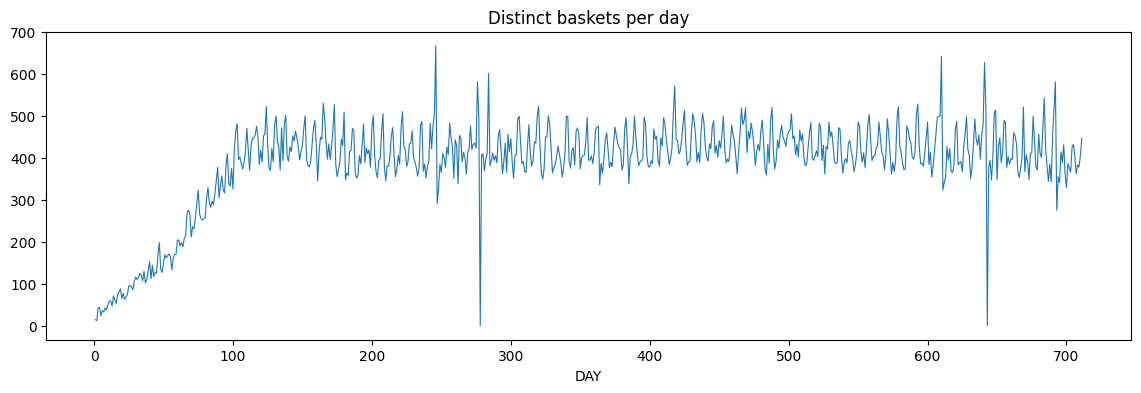

In [18]:
# Distinct baskets per day across the full history, to check for gaps or a collection cutoff
daily = transactions.groupby("DAY")["BASKET_ID"].nunique()
daily.plot(figsize=(14,4), lw=0.8, title="Distinct baskets per day")

In [19]:
# Distribution of each household's first observed day, to check whether the panel fills in gradually
first_day = transactions.groupby("household_key")["DAY"].min()
first_day.describe()

count    2500.000000
mean       65.941200
std        39.152355
min         1.000000
25%        36.000000
50%        69.000000
75%        95.000000
max       671.000000
Name: DAY, dtype: float64

In [20]:
# Count households that only enter the panel very late
first_day = transactions.groupby("household_key")["DAY"].min()
print((first_day > 594).sum())
print((first_day > 500).sum())

2
2


### Time series sanity check — conclusions

Before building the label, the daily transaction volume was inspected to
confirm the outcome window (days 684-711) is usable.

**The outcome window is clean.** Days 650-711 sit in the same 350-500
baskets/day band as the rest of the series, with the same weekly
seasonality. There is no truncation or structural decline at the end of
the data, so a household with no purchase in 684-711 is genuinely absent,
not an artefact of collection stopping.

**The panel ramps up over the first ~95 days.** Volume climbs from ~20 to
~450 baskets/day before flattening. This is households entering the panel
progressively, not business growth. Confirmed by the distribution of each
household's first observed day:

Half the households only appear after day 69. A household absent on day 40
was not inactive, it was not being observed.

*Consequence:* features must be computed over **windows anchored at T**
(last 28 / 90 / 180 days before day 683) rather than over full history.
Whole-history aggregates such as "total visits" would partly measure
length of panel membership instead of behaviour.

**Late entrants are negligible.** Only 2 of 2,500 households first appear
after day 500. No exclusion rule is warranted for 0.08% of the base; they
are handled by a `tenure_days = 683 - first_day` feature instead.

**Confirmed:** `DAY` runs 1-711, so the cutoff is fixed at **T = 683**.

## Building the label

    observation : days 1-683    (features only)
    outcome     : days 684-711  (label only, 28 days)

T = 683 is forced by the data: outcome must be 28 days, data ends at 711.

**Eligible population**: at least one purchase in the 90 days before T
(days 594-683): **2,323 of 2,500**, removing 7.1%.

The 90-day threshold defines *who the question is asked about*, which is
separate from the 28-day definition of the event.

**Label**: `churn = 1` if no purchase in days 684-711.

**Consequences**: imbalance is 6.4:1, so no resampling; accuracy is
unusable (predicting "nobody leaves" scores 84.4%), so PR-AUC is the
primary metric. With ~290 positives in training, flexible models will
memorise and model selection must come from CV variance, not a single
test-set comparison.

### Building the eligible-population table

Before labelling, restrict to households the churn question actually applies
to: those with at least one purchase in the 90 days before T.

In [21]:
T = 683
OUTCOME_DAYS = 28
ELIGIBILITY_DAYS = 90

# Eligible: at least one purchase in the 90 days before T
eligible = (
    transactions.loc[transactions["DAY"].between(T - ELIGIBILITY_DAYS + 1, T), "household_key"]
    .unique()
)

eligible = pd.Series(sorted(eligible), name ="household_key")

print(f"households in transactions : {transactions['household_key'].nunique():,}")
print(f"eligible at T={T}          : {len(eligible):,}")

households in transactions : 2,500
eligible at T=683          : 2,323


**Result:** the eligibility filter removes long-inactive households from the
population entirely — they aren't candidates for churning now, since they
left long before T.

### Calculating Churn

Apply the label definition from the top of the notebook to the eligible
population: did the household buy anything in the 28-day outcome window?

In [22]:
# Who bought in the outcome window?
buyers_in_outcome = set(
    transactions.loc[transactions["DAY"].between(T+1, T + OUTCOME_DAYS), "household_key"]
)

households = pd.DataFrame({"household_key": eligible})
households["churn"] = (~households["household_key"].isin(buyers_in_outcome)).astype(int)

print(households["churn"].value_counts())
print(f"\nchurn rate: {households['churn'].mean():.1%}")

churn
0    1960
1     363
Name: count, dtype: int64

churn rate: 15.6%


**Result:** every eligible household now has a clean 0/1 label, built purely
from the outcome window — none of it derived from data the model will also
see as a feature.

# Test and Training Split

The split is on **households**, not on time, since the time split (T = 683) was
already done when building the label. Two different cuts, two purposes:
T protects against predicting the present with the present, this one
protects against memorising instead of learning.

Stratified on `churn`: with only 363 positives, an unstratified draw can
easily land 14% on one side and 18% on the other by chance alone.
`random_state` fixed so the split is reproducible.

Test size is 20%, leaving ~73 positives for the final evaluation. That is
small, and it is the ceiling this dataset allows as a larger test set would
starve an already-thin training positive class.


**Model selection comes from cross-validation on the training set, not from comparing test scores.**


**Rule from here on:** `test_hh` is not opened, plotted or described until
the final evaluation. All EDA and all model selection happen on `train_hh`.

In [23]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

train_hh, test_hh = train_test_split(
    households,
    test_size=0.20,
    stratify=households["churn"],
    random_state=RANDOM_STATE
)

print(f"train : {len(train_hh):>5,}  churn {train_hh['churn'].mean():.1%}  ({train_hh['churn'].sum()} positives)")
print(f"test  : {len(test_hh):>5,}  churn {test_hh['churn'].mean():.1%}  ({test_hh['churn'].sum()} positives)")

train : 1,858  churn 15.6%  (290 positives)
test  :   465  churn 15.7%  (73 positives)


Both splits keep the churn rate close to the full eligible population, so
stratification worked as intended. From this point on, `test_hh` is set
aside untouched.

# Building Features

**Construction decisions**

* `QUANTITY` is not used. Fuel purchases (`KIOSK-GAS`) record hundredths of
  a gallon, so summing quantity across departments produces values in the
  hundreds of thousands. Basket size is measured as distinct products per
  visit instead.
* `visits_180d` correlates 0.97 with `visits_90d` — the same variable at two
  scales. It is replaced by `visit_trend = visits_90d / visits_180d`, where
  0.5 is a steady pace.
* Demographic attributes are not used. `hh_demographic` covers 801 of 2,500
  households (32%), and missingness inside it pushes effective coverage
  lower still — `MARITAL_STATUS_CODE` is populated for roughly 18% of the
  base. Using it would mean either training on a third of the data, losing
  most of an already-thin positive class, or imputing "unknown" for
  two-thirds of rows. This is a first-version decision: once a behavioural
  baseline exists, the 801-household subset can test whether demographics
  add anything measurable.

**Findings**

* Level features separate the classes strongly: `visits_90d` (14 vs 3),
  `spend_90d` (401 vs 94), `distinct_products_90d` (105 vs 27) and
  `recency` (4 vs 24.5), stayed vs churned medians.
* `basket_size_90d` does not separate (7.44 vs 7.20). The hypothesis that a
  fuller basket signals loyalty does not hold: what changes before churn is
  visit frequency, not basket size.
* `tenure_days` does not separate either (613 vs 617), correlates with
  nothing, and is largely an artefact of panel design — households entered
  the panel progressively over the first ~95 days.
* `visit_trend` has identical medians across classes (0.50) but different
  shapes. Churners concentrate at both extremes — those who slowed sharply
  (~0.2) and those whose 90-day visits are all of their 180-day visits
  (1.0: recent arrivals or returners after a gap). Non-churners cluster in
  the middle. A median comparison misses this entirely; the per-class
  histogram is what exposes it. Note the consequence: a linear model cannot
  capture a U-shaped relationship without an explicit interaction or
  binning term — it can only draw one boundary through `visit_trend`, not
  two, so a tree-based model has an inherent edge on this particular
  feature.


## Features Function

A single function turns raw transactions into one row per household,
respecting the cutoff so no post-T information can leak in.

In [24]:
def build_features(household_keys, transactions, cutoff=683):
    """
    Aggregate transactions into one row per household.
    Only data up to `cutoff` is used so the outcome window never enters here.
    """

    household_keys = pd.Index(household_keys, name="household_key")

    tx = transactions[
        (transactions["DAY"]<=cutoff)
        & (transactions["household_key"].isin(household_keys))
    ]

    g = tx.groupby("household_key")
    feats = pd.DataFrame(index=household_keys)
    feats["recency"] = cutoff - g["DAY"].max()
    feats["tenure_days"] = cutoff - g["DAY"].min()

    for w in (90, 180):
        win = tx[tx["DAY"] > cutoff - w].groupby("household_key")
        feats[f"visits_{w}d"] = win["BASKET_ID"].nunique()

    win90 = tx[tx["DAY"] > cutoff - 90].groupby("household_key")
    feats["spend_90d"]             = win90["SALES_VALUE"].sum()
    feats["distinct_products_90d"] = win90["PRODUCT_ID"].nunique()

    # counts and sums are genuinely zero when a window is empty
    count_cols = ["visits_90d", "visits_180d", "spend_90d",
                  "distinct_products_90d"]
    feats[count_cols] = feats[count_cols].fillna(0)

    # derived: average basket size, guarding against division by zero
    feats["basket_size_90d"] = (
        feats["distinct_products_90d"] / feats["visits_90d"].replace(0, np.nan)
    ).fillna(0)

    # pace change: 0.5 = steady, below = slowing down
    # visits_180d is dropped afterwards (corr 0.97 with visits_90d)
    feats["visit_trend"] = (
        feats["visits_90d"] / feats["visits_180d"].replace(0, np.nan)
    ).fillna(0)

    return feats.drop(columns="visits_180d")

In [25]:
X_train = build_features(train_hh["household_key"], transactions)
X_train.head()


,recency,tenure_days,visits_90d,spend_90d,distinct_products_90d,basket_size_90d,visit_trend
household_key,,,,,,,
2392,1,671,13,317.92,96,7.384615,0.520000
671,6,606,19,629.61,84,4.421053,0.542857
887,11,678,8,128.53,58,7.250000,0.615385
2468,21,608,7,57.08,37,5.285714,0.500000
1963,2,612,6,416.44,143,23.833333,0.545455


In [26]:
X_train.describe().T

,count,mean,std,min,25%,50%,75%,max
recency,1858.0,12.056512,17.422914,0.000000,1.000000,5.000000,14.000000,89.0
tenure_days,1858.0,616.874058,38.420473,12.000000,588.000000,614.000000,647.000000,682.0
visits_90d,1858.0,16.226588,17.148495,1.000000,5.000000,11.000000,21.000000,168.0
spend_90d,1858.0,508.839909,557.809596,0.690000,131.160000,317.215000,692.010000,6783.3
distinct_products_90d,1858.0,119.560818,106.376450,1.000000,39.000000,89.000000,173.000000,747.0
basket_size_90d,1858.0,9.075946,6.941318,0.333333,4.591176,7.422222,11.453297,72.0
visit_trend,1858.0,0.523234,0.177237,0.050847,0.423368,0.500000,0.600000,1.0


In [27]:
y_train = train_hh.set_index("household_key")["churn"].reindex(X_train.index)

**Result:** `X_train` has one row per training household and seven
behavioural features, all computed from data no later than T. `y_train`
holds the matching label. This is the matrix the rest of the notebook
explores and models.

# EDA

With the feature matrix built, look at how each feature actually relates to
churn before fitting anything — distributions, medians and correlations,
all on `train_hh` only.

## Evaluating histograms of features against churn

Plot each feature's full distribution split by outcome, not just a summary
statistic — a median comparison alone can hide shape differences that
matter (see `visit_trend` below).

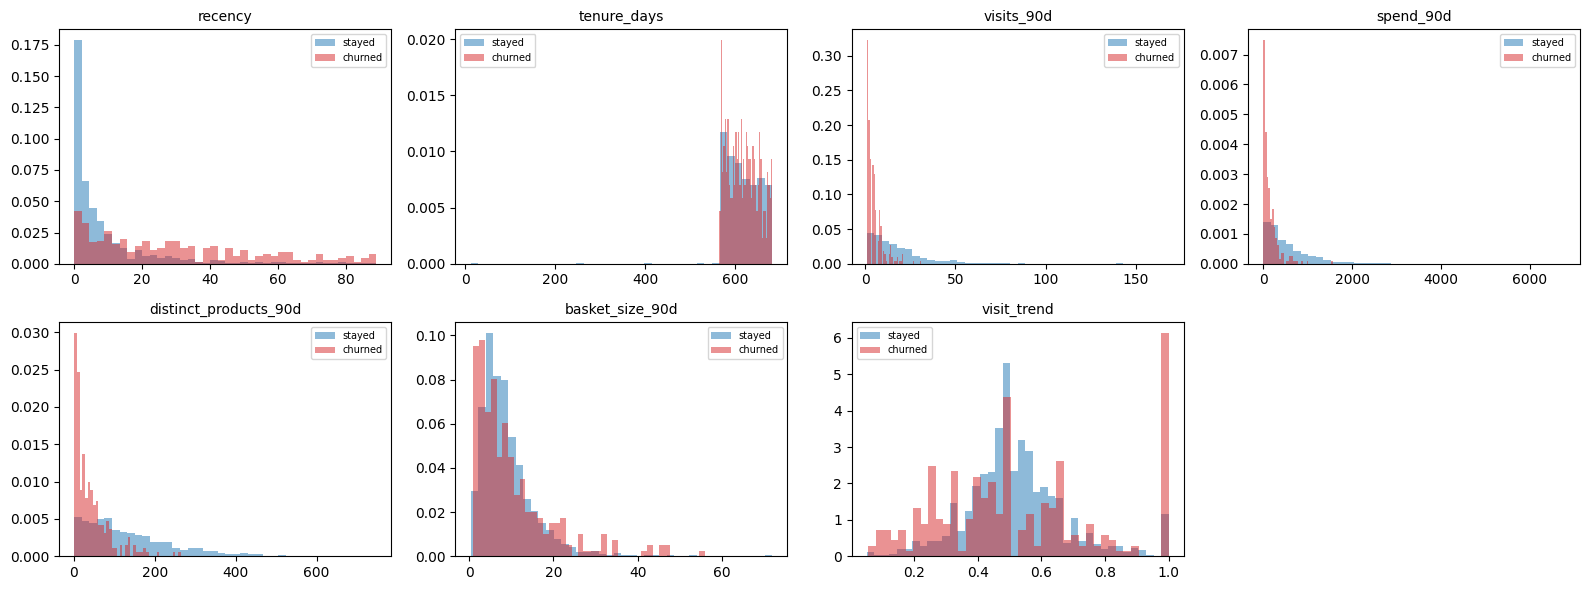

In [28]:
# Compare each feature's distribution between churned and retained households
fig, axes = plt.subplots(2, 4, figsize=(16, 6))

for ax, col in zip(axes.ravel(), X_train.columns):
    for churn_val, label, color in [(0, "stayed", "tab:blue"), (1, "churned", "tab:red")]:
        X_train.loc[y_train == churn_val, col].plot.hist(
            ax=ax, bins=40, alpha=0.5, density=True, label=label, color=color
        )
    ax.set_title(col, fontsize=10)
    ax.set_ylabel("")
    ax.legend(fontsize=7)

axes.ravel()[-1].axis("off")   # 7 features, 8 slots
plt.tight_layout()

**Result:** the shapes confirm the median-level findings from Building
Features — `visits_90d`, `spend_90d`, `distinct_products_90d` and `recency`
visibly separate the two classes, while `basket_size_90d` and `tenure_days`
overlap almost completely. `visit_trend` is the one feature where the
histogram tells a different story than the median: churners cluster at both
tails, not just the low end.

## Evaluating patterns of churned customers across features

A per-feature median table, side by side for churned vs. retained
households, as a compact companion to the histograms above.

In [29]:
# Compare feature medians between churned and retained households
X_train.assign(churn=y_train).groupby("churn").median().T

churn,0,1
recency,4.000000,24.50
tenure_days,613.000000,617.00
visits_90d,14.000000,3.00
spend_90d,401.110000,93.66
distinct_products_90d,105.500000,27.00
basket_size_90d,7.444444,7.20
visit_trend,0.500000,0.50


**Result:** the widest gaps are in the frequency and spend features; basket
size and tenure are close enough to be uninformative on their own, matching
what the histograms already showed.

## Checking correlation between features

Before modelling, check which engineered features are redundant with each
other — redundant pairs make individual coefficients hard to trust, even
when the model as a whole performs well.

In [30]:
# Correlation matrix across the engineered features
X_train.corr().style.background_gradient(cmap="coolwarm", vmin=-1, vmax=1).format("{:.2f}")

,recency,tenure_days,visits_90d,spend_90d,distinct_products_90d,basket_size_90d,visit_trend
recency,1.00,0.01,-0.40,-0.37,-0.41,0.13,-0.08
tenure_days,0.01,1.00,0.01,-0.03,-0.01,-0.01,-0.04
visits_90d,-0.40,0.01,1.00,0.70,0.69,-0.23,0.03
spend_90d,-0.37,-0.03,0.70,1.00,0.92,0.11,0.02
distinct_products_90d,-0.41,-0.01,0.69,0.92,1.00,0.22,0.02
basket_size_90d,0.13,-0.01,-0.23,0.11,0.22,1.00,-0.05
visit_trend,-0.08,-0.04,0.03,0.02,0.02,-0.05,1.00


**Result:** `spend_90d` and `distinct_products_90d` are highly correlated —
the two are largely the same signal. This resurfaces later in First Cross
Validation, where the logistic model's coefficients on this pair turn out
to be unstable.

## Testing for GAS and Churn relationship

Fuel purchases (`KIOSK-GAS`) are a distinct, high-frequency product category.
The question is whether buying fuel at this retailer carries churn signal of
its own, or whether it's just another symptom of being a frequent shopper —
the same confound already anticipated for coupons and campaigns.

### Checking if it's representative

In [31]:
gas_products = product.loc[
    product["DEPARTMENT"].isin(["KIOSK-GAS"]), "PRODUCT_ID"
]

tx90 = transactions[
    (transactions["DAY"].between(594, 683))
    & (transactions["household_key"].isin(train_hh["household_key"]))
]

gas_hh = tx90.loc[tx90["PRODUCT_ID"].isin(gas_products), "household_key"].unique()
print(f"households buying fuel in 90d: {len(gas_hh)} of {len(train_hh)} ({len(gas_hh)/len(train_hh):.1%})")

households buying fuel in 90d: 524 of 1858 (28.2%)


### Checking if there's potential correlation

In [32]:
uses_gas = train_hh["household_key"].isin(gas_hh).values
pd.crosstab(uses_gas, y_train.values, normalize="index")

col_0,0,1
row_0,,
False,0.805097,0.194903
True,0.942748,0.057252


### Checking if GAS really influences churn or is just a consequence of high-frequency visits

In [33]:
bucket = pd.qcut(X_train["visits_90d"], 4, labels=["Q1", "Q2", "Q3", "Q4"])
pd.crosstab([bucket, uses_gas], y_train.values, normalize="index").round(3)

col_0                 0      1
visits_90d row_1              
Q1         False  0.581  0.419
           True   0.667  0.333
Q2         False  0.872  0.128
           True   0.840  0.160
Q3         False  0.954  0.046
           True   0.955  0.045
Q4         False  1.000  0.000
           True   0.992  0.008

**GAS conclusion: Simpson's paradox.**

Fuel purchase looked like a strong retention signal: households buying at
the gas kiosk churn at 5.7% versus 19.5% for those who don't, a 3.4x gap.
Controlling for visit frequency, the effect vanishes and even reverses in
the second quartile (16.0% vs 12.8%). The raw gap was composition: fuel
buyers concentrate in the high-frequency quartiles, and it is frequency
that predicts retention. The feature is not added.

# Baseline

**Metric decided before any model is trained.**

Accuracy is not usable: predicting "nobody leaves" scores 84.4%. Primary
metric is **PR-AUC** (average precision), which is sensitive to the
minority class; **ROC-AUC** is reported as secondary.

The baseline is a one-variable rule, not a model. Any model that does not
clearly beat it is not earning its complexity.

In [34]:
from sklearn.metrics import average_precision_score, roc_auc_score, precision_recall_fscore_support

# the rule outputs a score, not a class: higher recency = higher risk
baseline_score = X_train["recency"]

print(f"PR-AUC  : {average_precision_score(y_train, baseline_score):.3f}")
print(f"ROC-AUC : {roc_auc_score(y_train, baseline_score):.3f}")

PR-AUC  : 0.441
ROC-AUC : 0.796


In [35]:
from sklearn.metrics import precision_recall_fscore_support

for thr in (14, 21, 28, 35):
    pred = (X_train["recency"] > thr).astype(int)
    p, r, f, _ = precision_recall_fscore_support(y_train, pred, average="binary", zero_division=0)
    print(f"recency > {thr:>2}  →  flags {pred.sum():>4}  precision {p:.2f}  recall {r:.2f}")

recency > 14  →  flags  457  precision 0.40  recall 0.63
recency > 21  →  flags  349  precision 0.45  recall 0.54
recency > 28  →  flags  242  precision 0.52  recall 0.43
recency > 35  →  flags  173  precision 0.55  recall 0.33


**Baseline result**: ranking households by `recency` alone:

One column, no model, 2.8x better than chance. This is the number every
model has to beat.

Note the gap between the two metrics on the *same* rule: 0.796 looks like
a decent model, 0.441 does not. ROC-AUC divides false positives by 1,568
negatives, which flatters any classifier on a 15.6% positive class. Had
ROC-AUC been chosen as the primary metric, the project would start from an
apparently strong 0.80 with little visible room to improve.

**Expectation set before modelling:** 0.55-0.65 would be a solid result.


# First Cross Validation

Compare the recency-only baseline against a handful of models under
five-fold cross-validation, on PR-AUC, to see whether letting a model
combine the behavioural features beats the one-column rule — and by how
much.

In [36]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

models = {
    "baseline (recency)": None,
    "logistic": Pipeline([
        ("scale", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ]),
    "decision tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "random forest": RandomForestClassifier(
        n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1
    ),
}

for name, model in models.items():
    if model is None:
        print(f"{name:<20} PR-AUC 0.441  (single number, no CV — rule has nothing to fit)")
        continue
    scores = cross_val_score(model, X_train, y_train, cv=cv,scoring="average_precision", n_jobs=-1)
    print(f"{name:<20} PR-AUC {scores.mean():.3f} ± {scores.std():.3f}   folds: {np.round(scores, 3)}")

baseline (recency)   PR-AUC 0.441  (single number, no CV — rule has nothing to fit)
logistic             PR-AUC 0.512 ± 0.030   folds: [0.556 0.474 0.51  0.533 0.489]
decision tree        PR-AUC 0.221 ± 0.016   folds: [0.243 0.196 0.225 0.213 0.229]
random forest        PR-AUC 0.462 ± 0.047   folds: [0.484 0.377 0.463 0.517 0.471]


In [37]:
# Restrict depth and leaf size to reduce variance
rf_shallow = RandomForestClassifier(
    n_estimators=300, max_depth=4, min_samples_leaf=20,
    random_state=RANDOM_STATE, n_jobs=-1
)
print(cross_val_score(rf_shallow, X_train, y_train, cv=cv,
                      scoring="average_precision", n_jobs=-1).mean())

0.4925415817918797


In [38]:
# Inspect which features the logistic model weights most heavily
pipe = models["logistic"].fit(X_train, y_train)
coef = pd.Series(pipe["clf"].coef_[0], index=X_train.columns).sort_values()
print(coef.round(3))

visits_90d              -1.700
distinct_products_90d   -0.996
spend_90d               -0.031
tenure_days              0.063
visit_trend              0.123
basket_size_90d          0.156
recency                  0.380
dtype: float64


**First conclusions**

* Five-fold stratified cross-validation on the training set. PR-AUC, mean ±
standard deviation across folds.

* **The single tree is half as good as one column.** With ~232 positives per
training fold, an unpruned tree memorises individuals rather than patterns.
Complexity without control makes things worse, not better.

* **Restricting the forest gained +0.031.** The problem was variance, not
insufficient capacity — capping depth and leaf size closed most of the gap
to the logistic model. Note those values were chosen by hand, not searched,
which is what justifies tuning as the next step.

* **Logistic and restricted forest are a technical tie.** Comparing the same
folds pairwise, logistic wins 4 of 5 with a mean margin of +0.020 — smaller
than the fold-to-fold variation, and the order reverses in fold 4.

* **The logistic model is not the baseline in disguise.** Standardised
coefficients rank `visits_90d` (-1.70) and `distinct_products_90d` (-0.996)
well above `recency` (0.380). Recent frequency predicts churn better than
recency does, and combining the features buys +0.071 PR-AUC over the
one-column rule.

* `spend_90d` collapses to ~0 despite separating classes strongly on its own.
It correlates 0.92 with `distinct_products_90d`, so the model keeps one and
zeroes the other. Which one it keeps is unstable across samples — the two
coefficients should be read as a pair, not individually.

# Tuning Hyperparameters

The restricted random forest above used hand-picked `max_depth` and
`min_samples_leaf` values. A grid search checks a wider range of the same
kind of restriction — plus `max_features` — to see whether those hand-picked
values were already close to the best available, or whether there's a
better-regularised region left unexplored.

In [39]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_depth":         [3, 4, 6, None],
    "min_samples_leaf":  [5, 10, 20, 40],
    "max_features":      ["sqrt", 0.5],
}

grid = GridSearchCV(
    RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    param_grid,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1,
    return_train_score=True,
)
grid.fit(X_train, y_train)

print(f"best PR-AUC : {grid.best_score_:.3f}")
print(f"best params : {grid.best_params_}")

best PR-AUC : 0.499
best params : {'max_depth': 4, 'max_features': 0.5, 'min_samples_leaf': 20}


**Result:** the search moves within the same family of restrictions explored
by hand above — capping depth and leaf size — rather than finding a
qualitatively different regime. It formalises the earlier hand-tuned choice
rather than overturning it, which is consistent with the earlier finding
that the logistic model and the restricted forest were already a technical
tie.

# Re-engineering features

Testing additional candidate signals now that the behavioural features and a
CV harness both exist. Coupon redemption and campaign exposure were loaded
back in Data prep but couldn't be tested there — they need `train_hh`,
`X_train` and `y_train`, none of which existed yet. Store concentration is a
new candidate discovered from the transactions table itself. Each candidate
gets the same treatment: check coverage, check the raw association with
churn, then control for visit frequency before trusting it.

### Coupon redemption

In [40]:
# Coverage: households that redeemed a coupon in the 180 days before T (training set only)
redeemers = coupon_redempt.loc[
    coupon_redempt["DAY"].between(T - 180 + 1, T), "household_key"
].unique()

hh_train = set(train_hh["household_key"])
n = len(hh_train & set(redeemers))
print(f"redeemed a coupon in 180d before T: {n} of {len(hh_train)} ({n/len(hh_train):.1%})")

redeemed a coupon in 180d before T: 280 of 1858 (15.1%)


In [41]:
# Check how it crossreferences with churn
redeemed = train_hh["household_key"].isin(redeemers).values

print(pd.crosstab(redeemed, y_train.values, normalize="index").round(3))

col_0      0      1
row_0              
False  0.825  0.175
True   0.950  0.050


In [42]:
# Check how it behaves when separated by groups based on visit levels.
# Here we want to understand if coupon redemption genuinely has a direct connection with churn or is just a consequence of visits.
bucket = pd.qcut(X_train["visits_90d"], 4, labels=["Q1", "Q2", "Q3", "Q4"])
print(pd.crosstab([bucket, redeemed], y_train.values, normalize="index").round(3))

col_0                 0      1
visits_90d row_1              
Q1         False  0.587  0.413
           True   0.429  0.571
Q2         False  0.867  0.133
           True   0.853  0.147
Q3         False  0.958  0.042
           True   0.939  0.061
Q4         False  0.993  0.007
           True   1.000  0.000


In [43]:
print(pd.crosstab([bucket, redeemed], y_train.values).loc["Q1"])

col_0    0    1
row_1          
False  289  203
True     3    4


In [44]:
print(pd.crosstab([bucket, redeemed], y_train.values).loc["Q4"])

col_0    0  1
row_1        
False  294  2
True   157  0


**Coupon conclusion: features tested, not adopted**

* `coupon_redempt` covers 15.1% of training households in the 180 days before
T — enough to test.

* Redemption looked protective: households redeeming a coupon churn at 5.0%
versus 17.5% for those who don't. Split by visit-frequency quartile, the
gap is composition and the concentration is extreme

* Redeemers sit almost entirely in the quartiles where nobody churns. Within
quartiles the effect vanishes, and Q1 has too few redeemers to read either
way. The same structure as the fuel-kiosk result.

**Scope of this conclusion:** what was tested is binary redemption in a
180-day window. A change-based version (redeemed before, stopped since) was
not tested, and would have fewer cases per cell than this one did.

On this dataset, marketing exposure reads as a marker of an active customer
rather than an independent driver of retention. Note this is the opposite
of the conclusion drawn in the most-forked public notebook, which reads the
raw association and reports that churn falls as redemptions rise.

### Campaign exposure

In [45]:
# Campaigns whose period overlaps the 180d window before T
lo, hi = T - 180 + 1, T
camps_in_window = campaign_desc.loc[
    (campaign_desc["START_DAY"] <= hi) & (campaign_desc["END_DAY"] >= lo),
    "CAMPAIGN"
]
print(f"campaigns overlapping days {lo}-{hi}: {len(camps_in_window)} of {len(campaign_desc)}")

campaigns overlapping days 504-683: 15 of 30


In [46]:
# coverage on training households
recv = campaign_table.loc[
    campaign_table["CAMPAIGN"].isin(camps_in_window), "household_key"
].unique()

hh_train = set(train_hh["household_key"])
n = len(hh_train & set(recv))
print(f"received a campaign: {n} of {len(hh_train)} ({n/len(hh_train):.1%})")

received a campaign: 1107 of 1858 (59.6%)


In [47]:
received = train_hh["household_key"].isin(recv).values
print(pd.crosstab(received, y_train.values, normalize="index").round(3))
print()

bucket = pd.qcut(X_train["visits_90d"], 4, labels=["Q1","Q2","Q3","Q4"])
print(pd.crosstab([bucket, received], y_train.values, normalize="index").round(3))
print()
print(pd.crosstab([bucket, received], y_train.values))

col_0      0      1
row_0              
False  0.723  0.277
True   0.926  0.074

col_0                 0      1
visits_90d row_1              
Q1         False  0.551  0.449
           True   0.695  0.305
Q2         False  0.872  0.128
           True   0.860  0.140
Q3         False  0.925  0.075
           True   0.963  0.037
Q4         False  1.000  0.000
           True   0.995  0.005

col_0               0    1
visits_90d row_1          
Q1         False  210  171
           True    82   36
Q2         False  197   29
           True   190   31
Q3         False   98    8
           True   340   13
Q4         False   38    0
           True   413    2


**Campaign exposure: real signal but unclear cause**

* Campaigns overlapping the 180 days before T reach 59.6% of training
households which is good coverage, and enough cases in every quartile.

* Raw separation is large (7.4% churn with a campaign vs 27.7% without), and
unlike coupons it **survives** the frequency control, but only in Q1:

* Three explanations fit equally well and cannot be separated without random
assignment:

1. the campaign retained the customer;
2. the retailer targeted the low-frequency customers who still looked recoverable;
3. or receiving a campaign requires loyalty-programme enrolment, which is itself a marker of
attachment.

* The effect appearing *only* where churn risk is high is more
consistent with risk-based targeting than with campaigns working.

* The feature is tested in the model in a second phase regardless as a large effect confined to
one quartile is structure trees can use and the linear model cannot. But it
carries a production caveat the behavioural features don't: it encodes a
retailer decision, so if campaign policy changes, the column changes
meaning and the model degrades without any signal that it has.

In [48]:
# Adding campaign as a feature and testing impact on logistic regression and random forest
X_train_c = X_train.assign(received_campaign=received.astype(int))

for name, model in [("logistic", models["logistic"]), ("rf", rf_shallow)]:
    s = cross_val_score(model, X_train_c, y_train, cv=cv,scoring="average_precision", n_jobs=-1)
    print(f"{name:<10} {s.mean():.3f} ± {s.std():.3f}   {np.round(s,3)}")

logistic   0.512 ± 0.030   [0.556 0.476 0.512 0.532 0.486]
rf         0.503 ± 0.039   [0.539 0.459 0.475 0.559 0.481]


**Tested in the model: no gain.**
The Q1 effect is real but redundant as the behavioural features already carry whatever it encoded.
Whether campaigns cause retention is a separate question from whether they
add predictive information here, and the answer to the second is no.

### Store concentration

Share of a household's visits spent at its single most-used store, in the 90
days before T. Unlike coupons and campaigns, this candidate wasn't loaded in
Data prep — it's derived directly from `transactions`.

In [49]:
# Store concentration on the last 90 days before T

tx90 = transactions[
    (transactions["DAY"].between(T - 90 + 1, T))
    & (transactions["household_key"].isin(train_hh["household_key"]))
]

visits_per_store = tx90.groupby(["household_key", "STORE_ID"])["BASKET_ID"].nunique()
total_visits     = visits_per_store.groupby("household_key").sum()
top_store_visits = visits_per_store.groupby("household_key").max()

store_conc = (top_store_visits / total_visits).rename("store_concentration")
n_stores   = visits_per_store.groupby("household_key").size().rename("n_stores")

print(store_conc.describe().round(3))
print()
print(n_stores.describe().round(1))

count    1858.000
mean        0.783
std         0.215
min         0.214
25%         0.600
50%         0.833
75%         1.000
max         1.000
Name: store_concentration, dtype: float64

count    1858.0
mean        2.5
std         1.6
min         1.0
25%         1.0
50%         2.0
75%         3.0
max        13.0
Name: n_stores, dtype: float64


In [50]:
print((store_conc == 1.0).mean())
print(store_conc.value_counts().head())

0.3353067814854682
store_concentration
1.000000    623
0.500000    124
0.666667     74
0.800000     48
0.750000     47
Name: count, dtype: int64


In [51]:
bucket_v = pd.qcut(X_train["visits_90d"], 4, labels=["Q1","Q2","Q3","Q4"])
single = (store_conc == 1.0)

print(pd.crosstab([bucket_v, single], y_train.values, normalize="index").round(3))
print()
print(pd.crosstab([bucket_v, single], y_train.values))

col_0                               0      1
visits_90d store_concentration              
Q1         False                0.662  0.338
           True                 0.536  0.464
Q2         False                0.891  0.109
           True                 0.814  0.186
Q3         False                0.947  0.053
           True                 0.980  0.020
Q4         False                0.997  0.003
           True                 0.986  0.014

col_0                             0    1
visits_90d store_concentration          
Q1         False                129   66
           True                 163  141
Q2         False                269   33
           True                 118   27
Q3         False                340   19
           True                  98    2
Q4         False                378    1
           True                  73    1


In [52]:
X_train_s = X_train.assign(single_store=(store_conc == 1.0).astype(int))

for name, model in [("logistic", models["logistic"]), ("rf", rf_shallow)]:
    s = cross_val_score(model, X_train_s, y_train, cv=cv,scoring="average_precision", n_jobs=-1)
    print(f"{name:<10} {s.mean():.3f} ± {s.std():.3f}   {np.round(s,3)}")

logistic   0.513 ± 0.027   [0.552 0.476 0.51  0.532 0.492]
rf         0.496 ± 0.042   [0.535 0.437 0.483 0.552 0.474]


**Store concentration: real effect, no predictive gain**

Share of visits at the household's most-used store, in the 90 days before T. 

* Churn by concentration is U-shaped, and the worst group is the loyal one

* This refutes the hypothesis that spreading across stores signals migration
as the opposite holds. Unlike the marketing features, the effect **survives**
the frequency control in the two quartiles with enough cases.

A plausible reading, formed after seeing the result rather than before it:
multi-store use marks integration into the chain as one shop near home,
another near work, giving more touchpoints to lose. Single-store households
depend on one geographic convenience, and a change of job or route ends the
relationship.

**In the model: nothing.** Binary encoding gives no upgrade on models CV

### Feature Re-engineering: what four tests showed

Every candidate looked strong on raw association. Two were confounded with
visit frequency. The other two survived that test and still added nothing as
**a real effect is not the same as new information.** The seven behavioural
features already represent what those columns encoded, by other routes.

Marketing exposure, store geography, product category and basket
composition have now all been tested. The ceiling sits and does
not move. The binding constraint is not feature coverage, it is 290
positive cases.

# Where this leaves the project

A restricted random forest and a plain logistic regression both beat the
recency-only baseline by a wide margin and land in a technical tie with
each other; hyperparameter search mostly confirmed the hand-picked
regularisation rather than finding something better. Four additional
candidate features — coupon redemption, campaign exposure, fuel purchases
and store concentration — were tested and rejected: each looked like a
real effect on its own, but none survived scrutiny as *new* information
once the behavioural features and visit-frequency confound were accounted
for.

**Not yet done:** `test_hh` has been held out, untouched, since the split.
Final evaluation against it — and a decision on which model to ship — is
the next step.

# Final test with the Logistic Regression
Now we'll check for performance with the untouched dataset

In [53]:
# final model, chosen from CV before touching the test set
final_model = models["logistic"]
final_model.fit(X_train, y_train)

# same function, same cutoff: test features built identically
X_test = build_features(test_hh["household_key"], transactions)
y_test = test_hh.set_index("household_key")["churn"].reindex(X_test.index)

assert X_test.notna().all().all()
assert X_test["recency"].between(0, 89).all()
assert list(X_test.columns) == list(X_train.columns)
assert len(X_test) == len(test_hh)
print("test feature checks passed", X_test.shape)

test feature checks passed (465, 7)


In [54]:
from sklearn.metrics import average_precision_score, roc_auc_score

proba = final_model.predict_proba(X_test)[:, 1]

print(f"PR-AUC  : {average_precision_score(y_test, proba):.3f}")
print(f"ROC-AUC : {roc_auc_score(y_test, proba):.3f}")
print(f"chance  : {y_test.mean():.3f}")
print()
print(f"baseline on test (recency): {average_precision_score(y_test, X_test['recency']):.3f}")

PR-AUC  : 0.652
ROC-AUC : 0.897
chance  : 0.157

baseline on test (recency): 0.516


In [55]:
# the model's advantage over the baseline, on the same test set
print(f"model  {average_precision_score(y_test, proba):.3f}")
print(f"recency {average_precision_score(y_test, X_test['recency']):.3f}")
print(f"lift over baseline: {0.652 - 0.516:+.3f}")

# is the test set just easier? compare feature distributions
print(X_test.median().round(2))
print()
print(X_train.median().round(2))

model  0.652
recency 0.516
lift over baseline: +0.136
recency                    4.00
tenure_days              614.00
visits_90d                11.00
spend_90d                335.51
distinct_products_90d     98.00
basket_size_90d            7.60
visit_trend                0.50
dtype: float64

recency                    5.00
tenure_days              614.00
visits_90d                11.00
spend_90d                317.22
distinct_products_90d     89.00
basket_size_90d            7.42
visit_trend                0.50
dtype: float64


# Final evaluation

Model chosen from cross-validation before the test set was opened: logistic
regression. It won 4 of 5 paired folds against the tuned forest and had the
lower fold-to-fold spread (0.030 vs 0.043) — a technical tie resolved on
simplicity, not on 0.013 of PR-AUC.

| | PR-AUC |
|---|---|
| **model on test** | **0.652** |
| baseline (recency) on test | 0.516 |
| chance (test churn rate) | 0.157 |
| model in cross-validation | 0.512 |

**4.2x chance, and +0.136 over a one-column rule on the same households.**
ROC-AUC is 0.897 reported for comparability, but the PR-AUC is the honest
number on a 15.7% positive class.

**Why the test beat cross-validation, and why that is not leakage.** A test
score 0.14 above CV is the wrong direction and deserves suspicion.
But the baseline moved with it around 0.441 in CV, 0.516 on test and a leak in
`build_features` would lift the model without lifting a raw column. 
Feature medians are near-identical across the two sets (`visits_90d` 11 vs 11,
`tenure_days` 614 vs 614, `recency` 4 vs 5), so the test set is not
structurally different. With 73 positives, this is sampling variation: the
CV folds themselves ranged from 0.474 to 0.556, and the test set is smaller
than one fold.

**What this number is not.** A single test score with 73 positives carries a
wide interval. The defensible claim is that the model generalises and holds
its advantage over the baseline

In [56]:
from sklearn.metrics import precision_recall_curve
import numpy as np

prec, rec, thr = precision_recall_curve(y_test, proba)

for target_k in (25, 50, 75, 100):          # top-K households flagged
    idx = np.argsort(proba)[::-1][:target_k]
    hits = y_test.values[idx].sum()
    print(f"top {target_k:>3}  →  {hits:>2} churners caught "
          f"({hits/target_k:.0%} precision, {hits/y_test.sum():.0%} of all churners)")

top  25  →  18 churners caught (72% precision, 25% of all churners)
top  50  →  37 churners caught (74% precision, 51% of all churners)
top  75  →  44 churners caught (59% precision, 60% of all churners)
top 100  →  51 churners caught (51% precision, 70% of all churners)


**In operational terms.** Ranking the 465 test households by predicted risk
and contacting the top 50: 37 of them churned (74% precision), which is half
of all churners in the set and 4.7x better than picking 50 households at
random. 